In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

conn = sqlite3.connect("olist_kpi.db")

In [3]:
pd.read_sql_query("""
SELECT COUNT(*) AS order_count
FROM orders;
""", conn)

,order_count
0,99441


In [4]:
monthly_kpi = pd.read_sql_query("""
WITH order_month AS (
    SELECT
        strftime('%Y-%m', order_purchase_timestamp) AS month,
        order_id,
        SUM(price) AS order_revenue,
        MAX(delivery_days) AS delivery_days,
        MAX(avg_review_score) AS review_score
    FROM analytical_base
    GROUP BY
        strftime('%Y-%m', order_purchase_timestamp),
        order_id
)
SELECT
    month,
    SUM(order_revenue) AS revenue,
    AVG(order_revenue) AS average_order_value,
    AVG(delivery_days) AS average_delivery_days,
    AVG(review_score) AS average_review_score,
    COUNT(*) AS order_count
FROM order_month
GROUP BY month
ORDER BY month;
""", conn)

monthly_kpi

,month,revenue,average_order_value,average_delivery_days,average_review_score,order_count
0,2016-09,134.97,134.970000,54.813194,1.000000,1
1,2016-10,40325.11,152.170226,19.600559,4.011450,265
2,2016-12,10.90,10.900000,4.693021,5.000000,1
3,2017-01,111798.36,149.064480,12.647044,4.199055,750
4,2017-02,234223.40,141.695947,13.168825,4.202678,1653
5,2017-03,359198.85,141.083602,12.951184,4.187376,2546
6,2017-04,340669.68,147.924307,14.917913,4.137555,2303
7,2017-05,489338.25,137.997250,11.322363,4.238488,3546
8,2017-06,421923.37,134.584807,12.011573,4.222919,3135
9,2017-07,481604.52,124.381333,11.592732,4.258416,3872


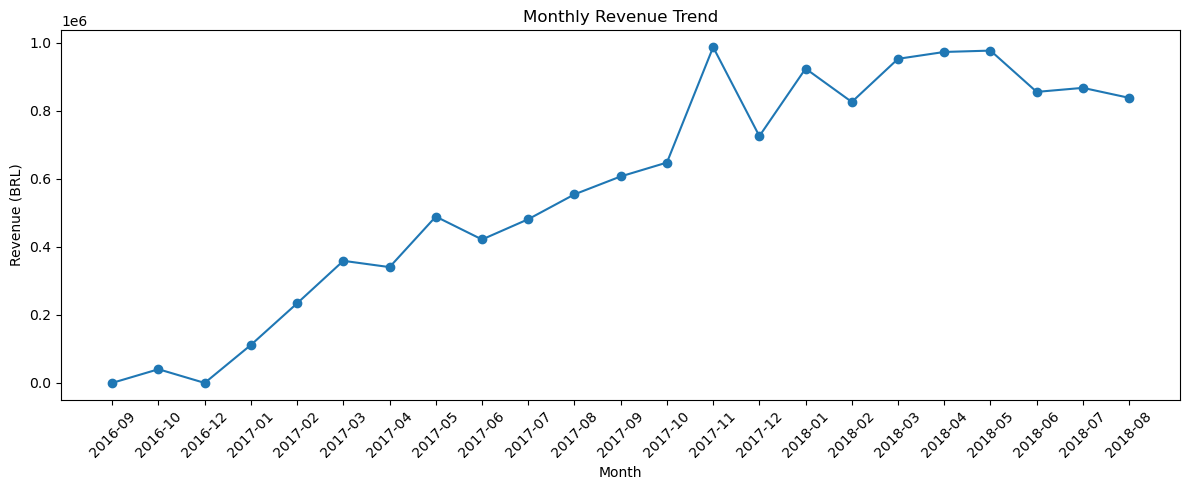

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_kpi["month"],
    monthly_kpi["revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (BRL)")
plt.xticks(rotation=45)

plt.savefig("monthly_revenue_trend.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [7]:
category_revenue = pd.read_sql_query("""
WITH category_order AS (
    SELECT
        category_name,
        order_id,
        SUM(price) AS order_revenue
    FROM analytical_base
    GROUP BY category_name, order_id
),
category_kpi AS (
    SELECT
        category_name,
        SUM(order_revenue) AS revenue,
        COUNT(*) AS order_count
    FROM category_order
    GROUP BY category_name
    HAVING COUNT(*) >= 100
)
SELECT
    category_name,
    revenue,
    order_count
FROM category_kpi
ORDER BY revenue DESC;
""", conn)

category_revenue

,category_name,revenue,order_count
0,health_beauty,1233131.72,8647
1,watches_gifts,1166176.98,5495
2,bed_bath_table,1023434.76,9272
3,sports_leisure,954852.55,7530
4,computers_accessories,888724.61,6530
5,furniture_decor,711927.69,6307
6,housewares,615628.69,5743
7,cool_stuff,610204.10,3559
8,auto,578966.65,3810
9,toys,471286.48,3804


In [8]:
top5 = category_revenue.head(5)
bottom5 = category_revenue.tail(5)

revenue_comparison = pd.concat([top5, bottom5])

revenue_comparison

,category_name,revenue,order_count
0,health_beauty,1233131.72,8647
1,watches_gifts,1166176.98,5495
2,bed_bath_table,1023434.76,9272
3,sports_leisure,954852.55,7530
4,computers_accessories,888724.61,6530
47,books_technical,18702.23,256
48,food_drink,14942.88,221
49,fashion_male_clothing,10452.33,106
50,fashion_underwear_beach,9305.95,117
51,christmas_supplies,8737.84,125


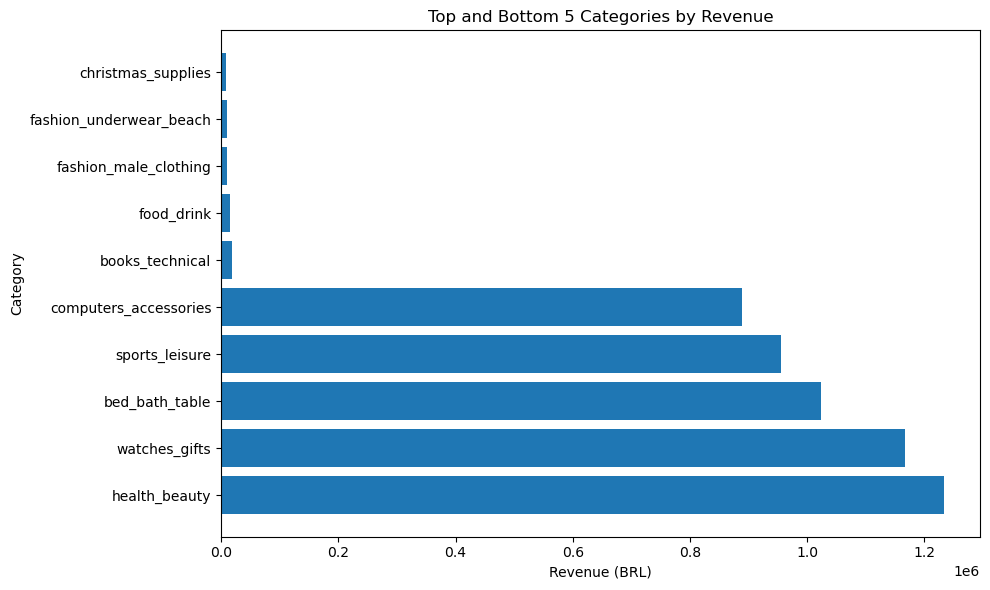

In [15]:
plt.figure(figsize=(10, 6))

plt.barh(
    revenue_comparison["category_name"],
    revenue_comparison["revenue"]
)

plt.title("Top and Bottom 5 Categories by Revenue")
plt.xlabel("Revenue (BRL)")
plt.ylabel("Category")
plt.savefig("top_bottom_categories_revenue.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [10]:
category_delivery = pd.read_sql_query("""
WITH category_order AS (
    SELECT
        category_name,
        order_id,
        MAX(delivery_days) AS delivery_days,
        MAX(avg_review_score) AS review_score
    FROM analytical_base
    GROUP BY category_name, order_id
)
SELECT
    category_name,
    AVG(delivery_days) AS average_delivery_days,
    AVG(review_score) AS average_review_score,
    COUNT(DISTINCT order_id) AS order_count
FROM category_order
GROUP BY category_name
HAVING COUNT(DISTINCT order_id) >= 100
ORDER BY average_delivery_days;
""", conn)

category_delivery

,category_name,average_delivery_days,average_review_score,order_count
0,food,9.792273,4.327231,441
1,construction_tools_lights,9.829345,4.150628,242
2,drinks,10.379629,4.236934,287
3,books_technical,10.634351,4.427451,256
4,food_drink,10.818937,4.445701,221
5,construction_tools_construction,10.855906,4.125171,736
6,luggage_accessories,10.866793,4.370443,1019
7,signaling_and_security,10.871064,4.116788,138
8,industry_commerce_and_business,10.894469,4.221739,232
9,small_appliances,10.975693,4.256623,609


In [11]:
correlation = category_delivery[
    ["average_delivery_days", "average_review_score"]
].corr()

correlation

,average_delivery_days,average_review_score
average_delivery_days,1.000000,-0.576532
average_review_score,-0.576532,1.000000


In [12]:
correlation_value = category_delivery[
    "average_delivery_days"
].corr(
    category_delivery["average_review_score"]
)

print("Correlation:", correlation_value)

Correlation: -0.5765321944967253


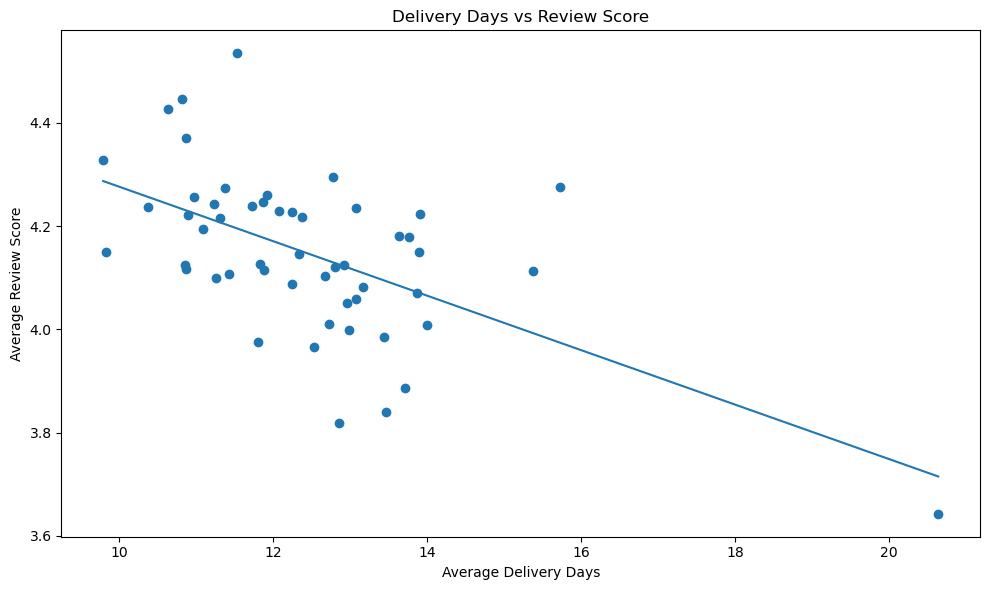

In [13]:
x = category_delivery["average_delivery_days"]
y = category_delivery["average_review_score"]

slope, intercept = np.polyfit(x, y, 1)

plt.figure(figsize=(10, 6))

plt.scatter(x, y)

plt.plot(
    x,
    slope * x + intercept
)

plt.title("Delivery Days vs Review Score")
plt.xlabel("Average Delivery Days")
plt.ylabel("Average Review Score")

plt.tight_layout()
plt.show()

## Conclusion

### Operational Insights

1. **Revenue is concentrated in a few major categories.**  
   Health & Beauty generated the highest revenue at approximately **BRL 1.23M**, followed by Watches & Gifts (**BRL 1.17M**) and Bed & Bath Table (**BRL 1.02M**). These categories should receive priority in inventory planning and operational capacity.

2. **Faster delivery is associated with higher customer satisfaction.**  
   The correlation between average delivery days and average review score is **-0.58**, indicating a moderate negative relationship. Reducing delivery times could help improve customer satisfaction.

3. **Office Furniture is a key service-risk category.**  
   It has an average delivery time of approximately **20.64 days** and the lowest average review score among the analyzed high-volume categories (**3.64**), with **1,254 orders**. This suggests a need to investigate its logistics and fulfillment processes.

4. **High revenue does not always mean high customer satisfaction.**  
   Bed & Bath Table generated more than **BRL 1.02M** in revenue but had an average review score of only **4.00**, while Books General Interest achieved a higher review score of **4.53** with much lower revenue. Revenue and customer experience should therefore be monitored together.

5. **Operational performance should scale with sales growth.**  
   Monthly revenue reached close to **BRL 1M** in several periods. As sales volume increases, maintaining efficient delivery and fulfillment becomes important to prevent operational issues from negatively affecting customer reviews.